# Project 3: Design and Implementation of a Sign Language Image Classifier
## Phase 1

### 0. Importation!

In [5]:
import os
import random
import sys
import subprocess
import pathlib

def install_package(package_name):
    print(f"Installing package '{package_name}'... Please wait.")
    subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])


# Loading Phase 1 Libraries

try:
    import cv2
except ImportError:
    install_package('opencv-python')
    import cv2

try:
    import numpy as np
except ImportError:
    install_package('numpy')
    import numpy as np

try:
    import matplotlib.pyplot as plt
except ImportError:
    install_package('matplotlib')
    import matplotlib.pyplot as plt

try:
    from sklearn.model_selection import train_test_split
except ImportError:
    install_package('scikit-learn')
    from sklearn.model_selection import train_test_split

# Loading Phase 2 Libraries

try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
    from torch.utils.data import Dataset, DataLoader
except ImportError:
    install_package('torch')
    import torch
    import torch.nn as nn
    import torch.optim as optim
    from torch.utils.data import Dataset, DataLoader

try:
    import torchvision.transforms as transforms
except ImportError:
    install_package('torchvision')
    import torchvision.transforms as transforms

try:
    from sklearn.metrics import confusion_matrix
except ImportError:
    install_package('scikit-learn')
    from sklearn.metrics import confusion_matrix


# Set default plot style
plt.style.use('ggplot')
print("\nAll imports for Phase 1 and Phase 2 are successfully completed!")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


All imports for Phase 1 and Phase 2 are successfully completed!
Using device: cpu


### 1. Data Loading and Exploration (EDA)
In this section, we define the dataset path and check if the data is balanced. To do this, we plot the number of samples per class using a bar chart.

Total number of classes: 29

Minimum samples in a class: 3000
Maximum samples in a class: 3000
The dataset is perfectly balanced!



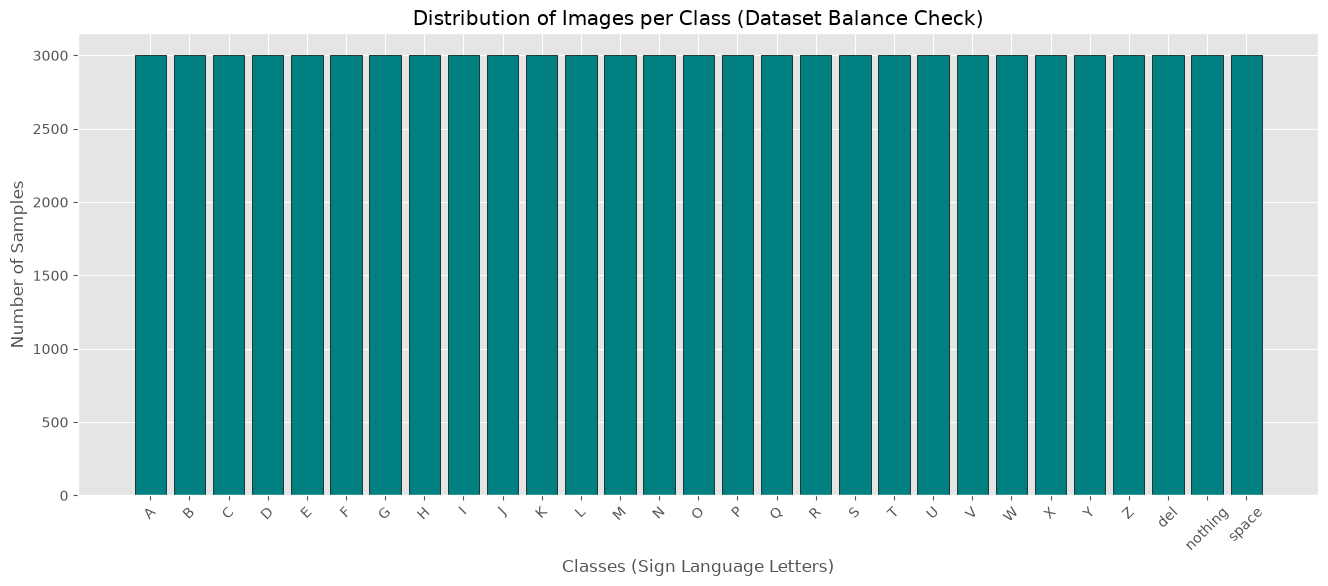

In [6]:
# Dataset path
dataset_path = r'alphabet/asl_alphabet_train/asl_alphabet_train'
classes = sorted(os.listdir(dataset_path))
print(f"Total number of classes: {len(classes)}\n")

# Count images per class
class_counts = {}
for c in classes:
    class_path = os.path.join(dataset_path, c)
    if os.path.isdir(class_path):
        class_counts[c] = len(os.listdir(class_path))

# Check balance
min_samples = min(class_counts.values())
max_samples = max(class_counts.values())
print(f"Minimum samples in a class: {min_samples}")
print(f"Maximum samples in a class: {max_samples}")

if min_samples == max_samples:
    print("The dataset is perfectly balanced!\n")
else:
    print("The dataset is imbalanced.\n")

# Plot
plt.figure(figsize=(16, 6))
plt.bar(class_counts.keys(), class_counts.values(), color='teal', edgecolor='black')
plt.title('Distribution of Images per Class (Dataset Balance Check)')
plt.xlabel('Classes (Sign Language Letters)')
plt.ylabel('Number of Samples')
plt.xticks(rotation=45)
plt.show()

### 2. Sample Visualization
To better understand the dataset, we randomly select one image from each class and display it along with its label in a grid.

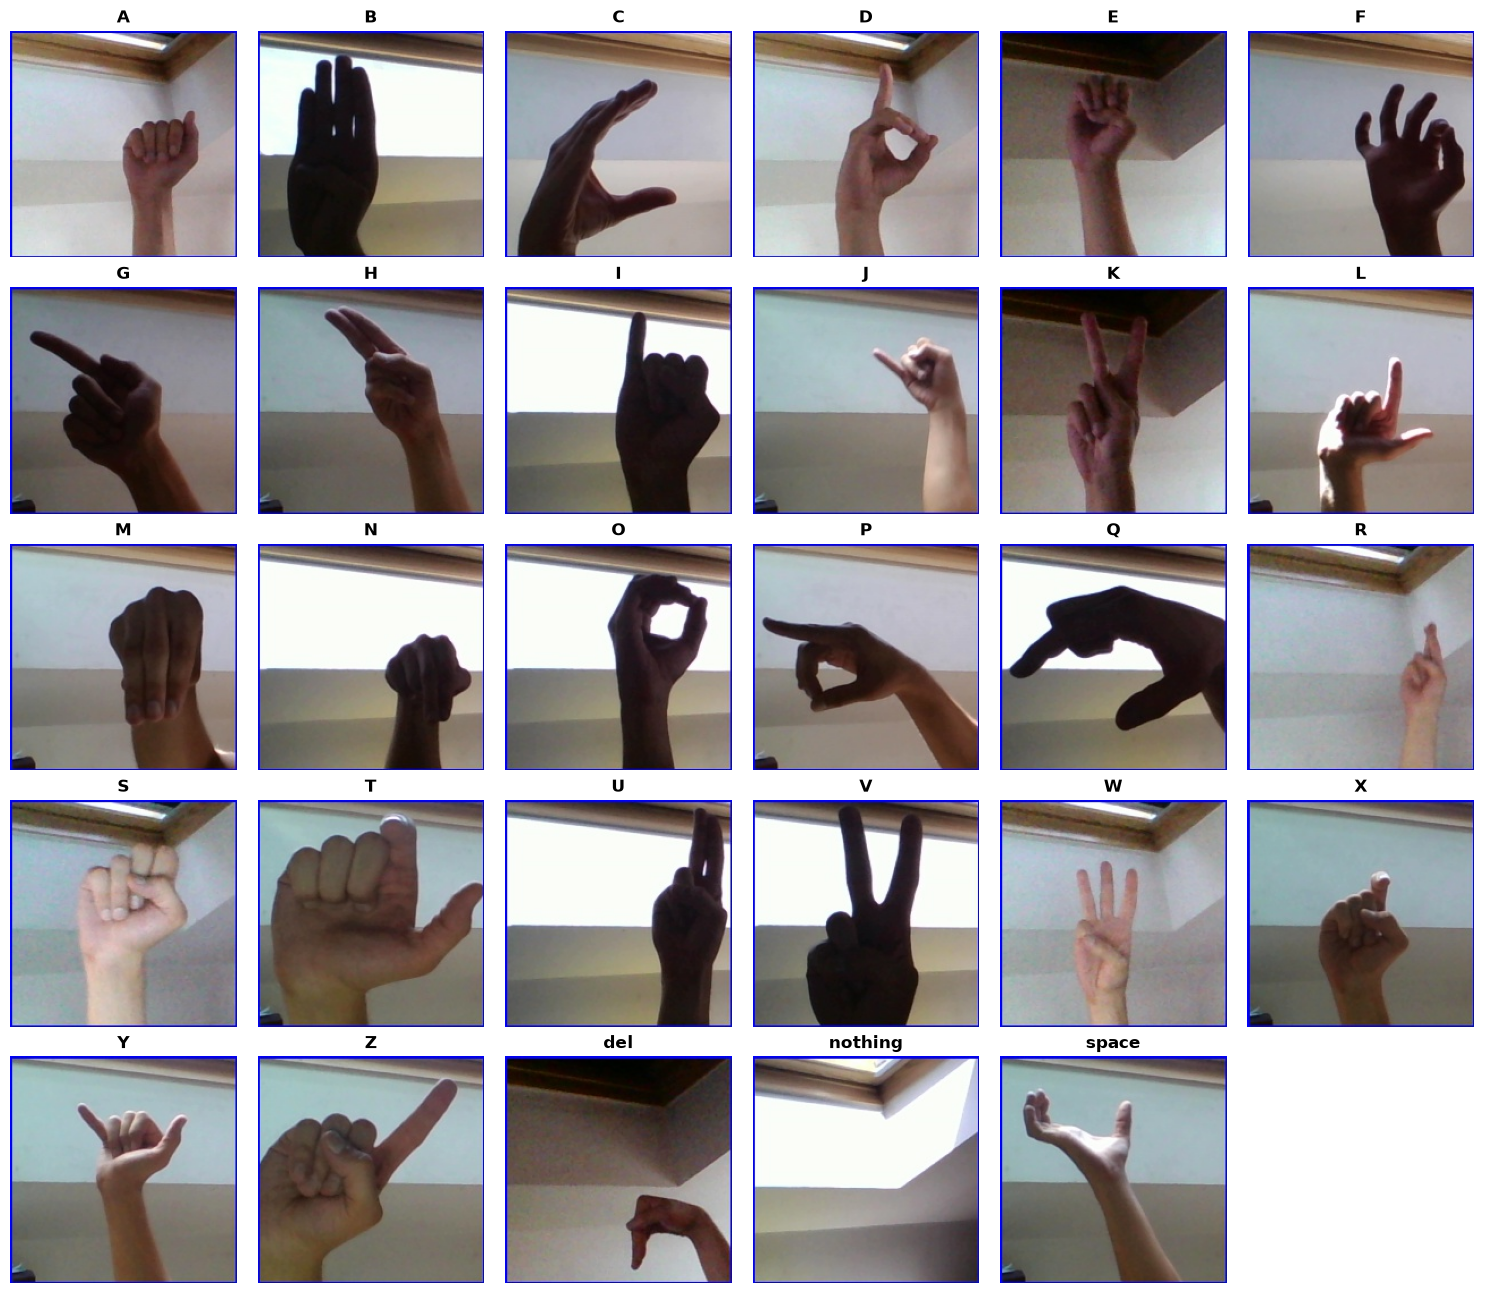

In [7]:
# Create a 5x6 grid (for 29 classes)
fig, axes = plt.subplots(5, 6, figsize=(15, 13))
axes = axes.flatten()

for i, c in enumerate(classes):
    class_path = os.path.join(dataset_path, c)
    images = os.listdir(class_path)
    
    # Random sample
    random_image_name = random.choice(images)
    img_path = os.path.join(class_path, random_image_name)
    
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Display
    axes[i].imshow(img)
    axes[i].set_title(c, fontsize=12, fontweight='bold')
    axes[i].axis('off')

# Turn off remaining empty axes
for j in range(len(classes), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

### 3. Data Splitting and Preprocessing Function
Images must be standardized before feeding them into the neural network. We will write a function to resize them (e.g., to 64x64) and normalize pixel values to the [0, 1] range. Then, we will split the entire dataset using the standard 80% Train, 10% Validation, and 10% Test ratio.

In [10]:
filepaths = []
labels = []

# Collect all paths and labels
for c in classes:
    class_path = os.path.join(dataset_path, c)
    if os.path.isdir(class_path):
        for img_name in os.listdir(class_path):
            filepaths.append(os.path.join(class_path, img_name))
            labels.append(c)

# Split data
# 'stratify' ensures class ratios are maintained across splits

# 80% Train,
X_train_paths, X_temp_paths, y_train, y_temp = train_test_split(
    filepaths, labels, test_size=0.20, random_state=42, stratify=labels
)

# 10% Validation, 10% Test
X_val_paths, X_test_paths, y_val, y_test = train_test_split(
    X_temp_paths, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"Training data count: {len(X_train_paths)}")
print(f"Validation data count: {len(X_val_paths)}")
print(f"Test data count: {len(X_test_paths)}\n")

def preprocess_image(image_path, size=(64, 64)):
    
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Resize
    img_resized = cv2.resize(img, size)
    
    # Normalize pixel values
    img_normalized = img_resized.astype(np.float32) / 255.0
    
    return img_normalized

# Apply preprocessing to all image paths for Train, Validation, and Test sets
print("Preprocessing training images...")
X_train = np.array([preprocess_image(p) for p in X_train_paths])

print("Preprocessing validation images...")
X_val = np.array([preprocess_image(p) for p in X_val_paths])

print("Preprocessing test images...")
X_test = np.array([preprocess_image(p) for p in X_test_paths])

# Print final shapes and value ranges to verify
print(f"\nX_train shape: {X_train.shape} | Min: {X_train.min():.1f}, Max: {X_train.max():.1f}")
print(f"X_val shape:   {X_val.shape}   | Min: {X_val.min():.1f}, Max: {X_val.max():.1f}")
print(f"X_test shape:  {X_test.shape}  | Min: {X_test.min():.1f}, Max: {X_test.max():.1f}")

# Test on a single sample
sample_img = preprocess_image(X_train_paths[0], size=(64, 64))
print(f"Output image shape after preprocessing: {sample_img.shape}")
print(f"Min pixel value: {sample_img.min():.1f} | Max pixel value: {sample_img.max():.1f}")

Training data count: 69600
Validation data count: 8700
Test data count: 8700

Preprocessing training images...
Preprocessing validation images...
Preprocessing test images...

X_train shape: (69600, 64, 64, 3) | Min: 0.0, Max: 1.0
X_val shape:   (8700, 64, 64, 3)   | Min: 0.0, Max: 1.0
X_test shape:  (8700, 64, 64, 3)  | Min: 0.0, Max: 1.0
Output image shape after preprocessing: (64, 64, 3)
Min pixel value: 0.0 | Max pixel value: 1.0


## Phase 2

### 1. Preparing Tensors and DataLoaders
We convert our preprocessed NumPy image matrices and string labels into PyTorch tensors, wrap them into `TensorDataset`, and create `DataLoaders` for batch processing.

In [12]:
from torch.utils.data import TensorDataset # این مورد در لیست ایمپورت‌های بالای شما نبود

# Map class names to indices
class_to_idx = {cls_name: i for i, cls_name in enumerate(classes)}
idx_to_class = {i: cls_name for cls_name, i in class_to_idx.items()}

# Convert string labels to integer tensors
y_train_idx = torch.tensor([class_to_idx[l] for l in y_train], dtype=torch.long)
y_val_idx = torch.tensor([class_to_idx[l] for l in y_val], dtype=torch.long)
y_test_idx = torch.tensor([class_to_idx[l] for l in y_test], dtype=torch.long)

# Convert NumPy arrays to PyTorch tensors and permute dimensions from (N, H, W, C) to (N, C, H, W)
X_train_tensor = torch.tensor(X_train, dtype=torch.float32).permute(0, 3, 1, 2)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32).permute(0, 3, 1, 2)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).permute(0, 3, 1, 2)

# Create TensorDatasets
train_dataset = TensorDataset(X_train_tensor, y_train_idx)
val_dataset = TensorDataset(X_val_tensor, y_val_idx)
test_dataset = TensorDataset(X_test_tensor, y_test_idx)

# Hyperparameter Tuning: Batch Size
BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"DataLoaders are ready with Batch Size = {BATCH_SIZE}")
print(f"Training batches: {len(train_loader)}")

DataLoaders are ready with Batch Size = 64
Training batches: 1088


### 2. CNN Architecture Definition (Functional Style)
We define our convolutional and fully-connected layers, and explicitly use `F.relu` for non-linear activation inside the `forward` pass.

In [13]:
import torch.nn.functional as F

class SignLanguageCNN(nn.Module):
    def __init__(self, num_classes=29):
        super(SignLanguageCNN, self).__init__()
        
        # Convolutional Layers
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        
        # Max Pooling Layer
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Fully Connected Layers
        self.fc1 = nn.Linear(128 * 8 * 8, 512)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        # Block 1
        x = self.pool(F.relu(self.conv1(x)))
        
        # Block 2
        x = self.pool(F.relu(self.conv2(x)))
        
        # Block 3
        x = self.pool(F.relu(self.conv3(x)))
        
        # Flatten feature maps
        x = torch.flatten(x, 1)
        
        # Classifier
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        
        return x

# Instantiate the model and move it to the configured device (GPU/CPU)
model = SignLanguageCNN(num_classes=len(classes)).to(device)
print(model)

SignLanguageCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=8192, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=29, bias=True)
)


### 3. Hyperparameter Tuning & Training Loop
Configuring the optimizer (`Adam`), learning rate, and executing the training and validation logic over the specified number of epochs.

In [14]:
# Hyperparameters
LEARNING_RATE = 0.001
EPOCHS = 10

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

print(f"Training started with Learning Rate = {LEARNING_RATE} for {EPOCHS} epochs...\n")

for epoch in range(EPOCHS):
    # Training Phase
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total_train += labels.size(0)
        correct_train += predicted.eq(labels).sum().item()
        
    epoch_train_loss = running_loss / total_train
    epoch_train_acc = correct_train / total_train
    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc)
    
    # Validation Phase
    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total_val += labels.size(0)
            correct_val += predicted.eq(labels).sum().item()
            
    epoch_val_loss = val_loss / total_val
    epoch_val_acc = correct_val / total_val
    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)
    
    print(f"Epoch [{epoch+1}/{EPOCHS}] | "
          f"Train Loss: {epoch_train_loss:.4f} - Train Acc: {epoch_train_acc*100:.2f}% | "
          f"Val Loss: {epoch_val_loss:.4f} - Val Acc: {epoch_val_acc*100:.2f}%")

print("\nTraining completed successfully!")

Training started with Learning Rate = 0.001 for 10 epochs...

Epoch [1/10] | Train Loss: 0.7963 - Train Acc: 74.92% | Val Loss: 0.1198 - Val Acc: 96.06%
Epoch [2/10] | Train Loss: 0.0933 - Train Acc: 96.91% | Val Loss: 0.1091 - Val Acc: 96.51%
Epoch [3/10] | Train Loss: 0.0493 - Train Acc: 98.46% | Val Loss: 0.0348 - Val Acc: 98.85%
Epoch [4/10] | Train Loss: 0.0350 - Train Acc: 98.97% | Val Loss: 0.0490 - Val Acc: 98.63%
Epoch [5/10] | Train Loss: 0.0281 - Train Acc: 99.12% | Val Loss: 0.0706 - Val Acc: 98.14%
Epoch [6/10] | Train Loss: 0.0239 - Train Acc: 99.32% | Val Loss: 0.0201 - Val Acc: 99.48%
Epoch [7/10] | Train Loss: 0.0196 - Train Acc: 99.47% | Val Loss: 0.0276 - Val Acc: 99.24%
Epoch [8/10] | Train Loss: 0.0197 - Train Acc: 99.39% | Val Loss: 0.0253 - Val Acc: 99.24%
Epoch [9/10] | Train Loss: 0.0111 - Train Acc: 99.70% | Val Loss: 0.0222 - Val Acc: 99.26%
Epoch [10/10] | Train Loss: 0.0194 - Train Acc: 99.46% | Val Loss: 0.0085 - Val Acc: 99.75%

Training completed success

### 4. Plotting Loss and Accuracy Curves
Visualizing the model's performance on both training and validation sets.

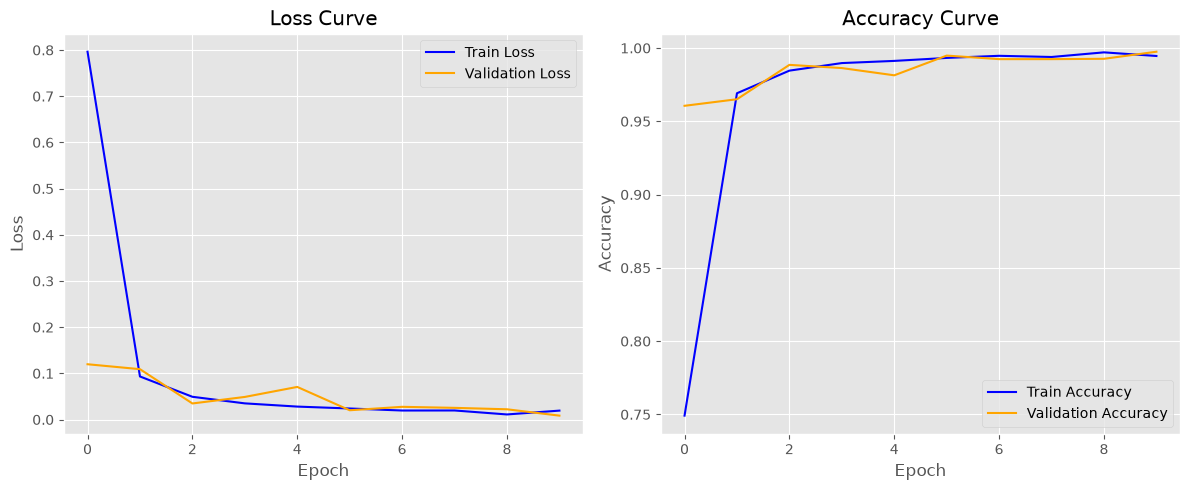

In [15]:
plt.figure(figsize=(12, 5))

# Loss Curves
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', color='blue')
plt.plot(val_losses, label='Validation Loss', color='orange')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy Curves
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy', color='blue')
plt.plot(val_accuracies, label='Validation Accuracy', color='orange')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

### 5. Model Evaluation & Confusion Matrix
Evaluating the trained model on the unseen test dataset and plotting the confusion matrix to identify misclassified sign language characters.

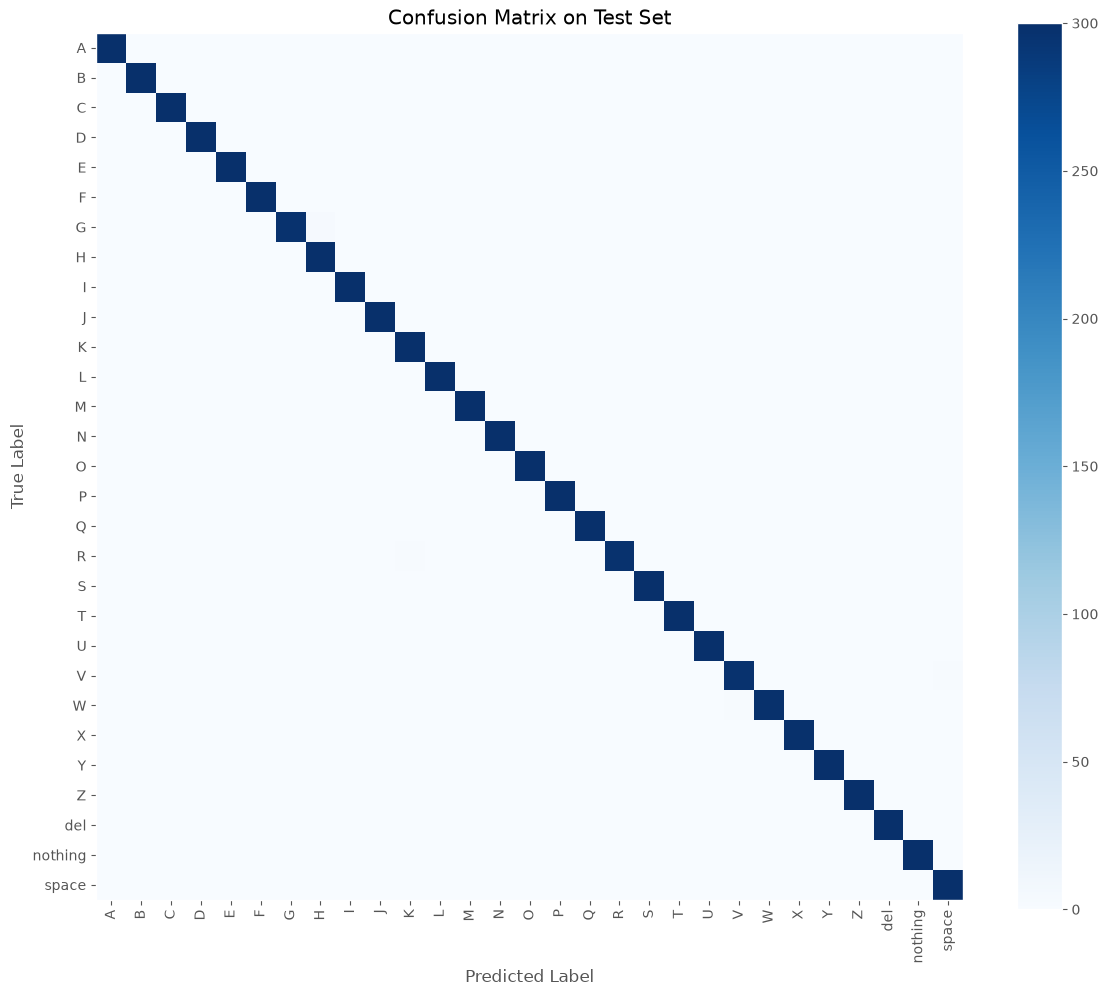

In [16]:
model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        
        # Transfer predictions back to CPU for plotting
        all_preds.extend(predicted.cpu().numpy())
        all_targets.extend(labels.numpy())

# Calculate Confusion Matrix
cm = confusion_matrix(all_targets, all_preds)

# Plot Confusion Matrix
plt.figure(figsize=(12, 10))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix on Test Set')
plt.colorbar()
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=90)
plt.yticks(tick_marks, classes)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.grid(False) # Turn off grid for better matrix visibility
plt.tight_layout()
plt.show()

### 6. Saving the Trained Model
After successfully training and evaluating the model, we save its learned weights (state_dict) to a `.pth` file. This allows us to load the trained model later for inference (e.g., live webcam prediction) without needing to retrain it.

In [ ]:
import os

# Define the path to save the model
MODEL_PATH = 'sign_language_cnn_model.pth'

# Save the model's state dictionary (weights and biases)
torch.save(model.state_dict(), MODEL_PATH)

print(f"Model weights successfully saved to: {os.path.abspath(MODEL_PATH)}")